# 🚍 GTFS Diagnostics — Operational Intelligence Report

> A comprehensive diagnostic analysis of a GTFS transit feed,
> extracting operational metrics, spatial patterns, and service quality
> indicators from schedule data.

### Contents

| # | Section | Key outputs |
|---|---|---|
| 1 | **Setup & Feed Overview** | Table counts, date range, agency info |
| 2 | **Service Profile** | Active trips over the day (10-min bins) |
| 3 | **Stop-level Analysis** | Headway & frequency maps, busiest stops |
| 4 | **Route Corridors** | Segment-level route concentration |
| 5 | **Service Kilometres** | Daily VKT, distance by route and time window |
| 6 | **Trip Summary Table** | Trips × time window, km/trip, total km |
| 7 | **Diagnostics** | Speed anomalies, stop spacing, trip duration outliers |

---
## 0 — Configuration

In [1]:
# ── Point this to your GTFS feed ─────────────────────────────────────
GTFS_PATH = "../data/processed/20260325_183744/gtfs.zip"

# Analysis date (None = auto-detect busiest date)
ANALYSIS_DATE: str | None = None

# Time windows for summary tables (hours)
TIME_WINDOWS = [
    ("Madrugada",  "00:00:00", "05:00:00"),
    ("Manhã Pico", "05:00:00", "09:00:00"),
    ("Entrepico",  "09:00:00", "16:00:00"),
    ("Tarde Pico",  "16:00:00", "20:00:00"),
    ("Noite",       "20:00:00", "24:00:00"),
]

# Headway computation window
HEADWAY_START = "06:00:00"
HEADWAY_END   = "22:00:00"

# CRS for distance calculations (UTM zone for your city)
# Set to None for auto-detection
LOCAL_CRS: int | None = None

---
## 1 — Setup & Feed Overview

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import geopandas as gpd
import gtfs_kit as gk
import json
import mapclassify
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import shapely.geometry as sg
from IPython.display import display, HTML

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", "{:.1f}".format)

# ── Plotting defaults ────────────────────────────────────────────────
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

# ── Color palette ────────────────────────────────────────────────────
PAL = {
    "primary": "#2196F3",
    "secondary": "#FF5722",
    "accent": "#4CAF50",
    "dark": "#263238",
    "light": "#ECEFF1",
    "ida": "#2196F3",
    "volta": "#FF5722",
}
WINDOW_COLORS = ["#455A64", "#2196F3", "#4CAF50", "#FF5722", "#9C27B0"]

In [3]:
# ── Read feed ────────────────────────────────────────────────────────
feed = gk.read_feed(GTFS_PATH, dist_units="km")

# Append shape_dist_traveled if missing
if feed.stop_times is not None and "shape_dist_traveled" not in feed.stop_times.columns:
    feed = feed.append_dist_to_stop_times()

print(f"Feed: {GTFS_PATH}")

Feed: ../data/processed/20260325_183744/gtfs.zip


In [4]:
# ── Detect analysis date ─────────────────────────────────────────────
if ANALYSIS_DATE is None:
    # Find the date with the most trips
    dates = feed.get_dates()
    trip_counts = {
        d: feed.compute_trip_activity([d])[d].sum() for d in dates[:30]
    }
    ANALYSIS_DATE = max(trip_counts, key=trip_counts.get)

print(f"Analysis date: {ANALYSIS_DATE} (busiest)")

# Auto-detect CRS
if LOCAL_CRS is None:
    shapes_gdf = gk.geometrize_shapes(feed.shapes)
    LOCAL_CRS = shapes_gdf.estimate_utm_crs().to_epsg()
print(f"Local CRS: EPSG:{LOCAL_CRS}")

Analysis date: 20260101 (busiest)
Local CRS: EPSG:32723


In [5]:
# ── Feed overview card ───────────────────────────────────────────────
agency = feed.agency.iloc[0] if feed.agency is not None else {}

overview = {
    "Operadora": agency.get("agency_name", "—"),
    "Timezone": agency.get("agency_timezone", "—"),
    "Rotas": len(feed.routes) if feed.routes is not None else 0,
    "Paradas": len(feed.stops) if feed.stops is not None else 0,
    "Viagens (total)": len(feed.trips) if feed.trips is not None else 0,
    "Shapes": feed.shapes["shape_id"].nunique() if feed.shapes is not None else 0,
    "Datas no feed": len(feed.get_dates()),
}

overview_df = pd.DataFrame(
    list(overview.items()), columns=["Métrica", "Valor"]
)
display(
    overview_df.style
    .set_properties(**{"font-weight": "bold"}, subset=["Métrica"])
    .hide(axis="index")
    .set_caption("Feed Overview")
)

Métrica,Valor
Operadora,Salineira
Timezone,America/Sao_Paulo
Rotas,23
Paradas,830
Viagens (total),1722
Shapes,46
Datas no feed,365


In [6]:
# ── Compute route time series (10-min bins) ──────────────────────────
rts = feed.compute_route_time_series(
    [ANALYSIS_DATE], freq="10min", split_directions=False,
)

# Aggregate across all routes → network-level time series
nts = (
    rts.groupby("datetime")
    .agg(
        num_trips=("num_trips", "sum"),
        num_trip_starts=("num_trip_starts", "sum"),
        service_distance=("service_distance", "sum"),
        service_duration=("service_duration", "sum"),
    )
    .reset_index()
)
nts["hour"] = pd.to_datetime(nts["datetime"]).dt.hour + pd.to_datetime(nts["datetime"]).dt.minute / 60

print(f"Time series: {len(nts)} bins, {nts['num_trips'].max():.0f} peak simultaneous trips")

Time series: 144 bins, 53 peak simultaneous trips


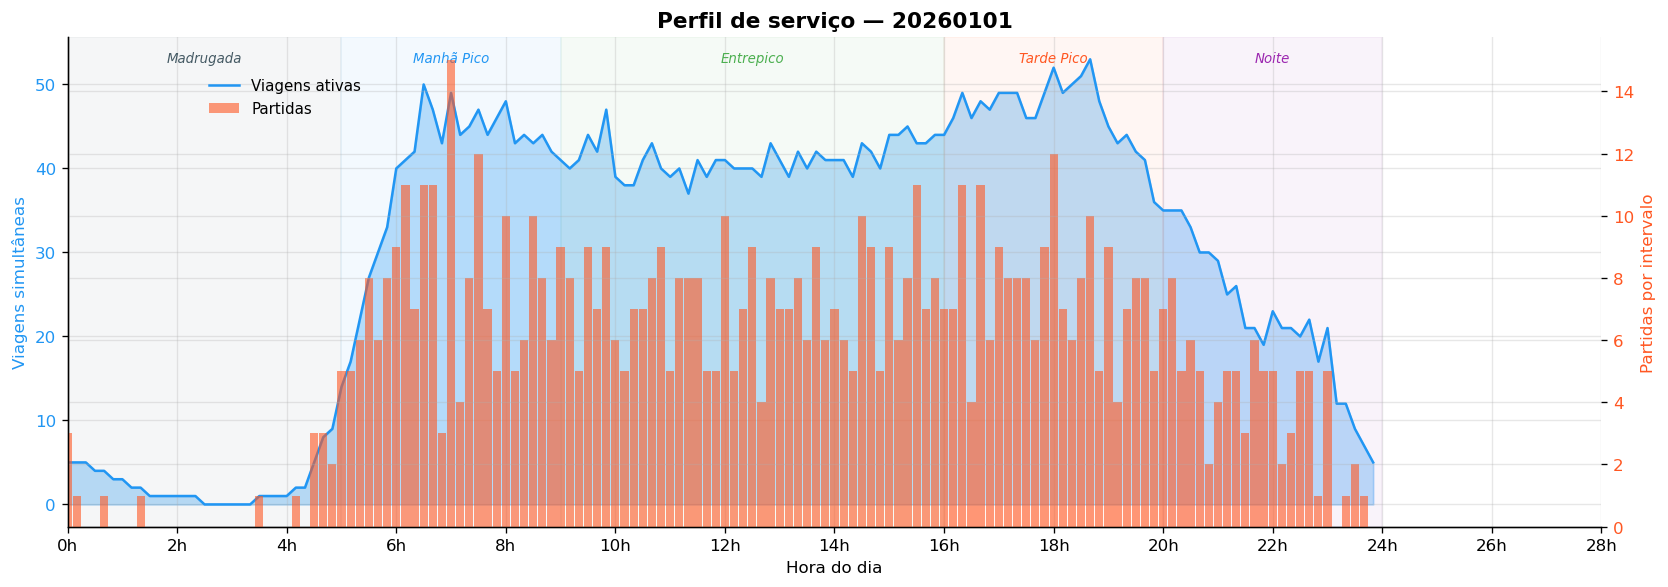

In [7]:
# ── Service profile plot ─────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

# Active trips (area)
ax1.fill_between(nts["hour"], nts["num_trips"], alpha=0.3, color=PAL["primary"])
ax1.plot(nts["hour"], nts["num_trips"], color=PAL["primary"], linewidth=1.5, label="Viagens ativas")
ax1.set_xlabel("Hora do dia")
ax1.set_ylabel("Viagens simultâneas", color=PAL["primary"])
ax1.tick_params(axis="y", labelcolor=PAL["primary"])
ax1.set_xlim(0, 28)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax1.xaxis.set_major_formatter(lambda x, _: f"{int(x)}h")

# Trip starts (bar on secondary axis)
ax2 = ax1.twinx()
ax2.bar(nts["hour"], nts["num_trip_starts"], width=0.15, alpha=0.6,
        color=PAL["secondary"], label="Partidas")
ax2.set_ylabel("Partidas por intervalo", color=PAL["secondary"])
ax2.tick_params(axis="y", labelcolor=PAL["secondary"])

# Time window shading
for i, (name, t0, t1) in enumerate(TIME_WINDOWS):
    h0 = int(t0.split(":")[0])
    h1 = int(t1.split(":")[0])
    ax1.axvspan(h0, h1, alpha=0.05, color=WINDOW_COLORS[i])
    ax1.text((h0 + h1) / 2, ax1.get_ylim()[1] * 0.97, name,
             ha="center", va="top", fontsize=8, color=WINDOW_COLORS[i], fontstyle="italic")

ax1.set_title(f"Perfil de serviço — {ANALYSIS_DATE}", fontsize=13, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

In [8]:
# ── Peak metrics ─────────────────────────────────────────────────────
peak_idx = nts["num_trips"].idxmax()
peak = nts.loc[peak_idx]

metrics = {
    "Pico de viagens simultâneas": f"{peak['num_trips']:.0f}",
    "Horário do pico": f"{peak['hour']:.1f}h",
    "Total de partidas no dia": f"{nts['num_trip_starts'].sum():.0f}",
    "Distância total (km)": f"{nts['service_distance'].sum():.0f}",
    "Duração total (h)": f"{nts['service_duration'].sum():.0f}",
    "Vel. média (km/h)": f"{nts['service_distance'].sum() / max(1, nts['service_duration'].sum()):.1f}",
}

display(
    pd.DataFrame(list(metrics.items()), columns=["Indicador", "Valor"])
    .style.hide(axis="index").set_caption("Métricas de pico")
)

Indicador,Valor
Pico de viagens simultâneas,53
Horário do pico,18.7h
Total de partidas no dia,781
Distância total (km),11788239
Duração total (h),607
Vel. média (km/h),19427.4


---
## 3 — Stop-level Analysis

### 3.1 Stop statistics & headway distribution

In [9]:
# ── Compute stop stats ───────────────────────────────────────────────
stop_stats = feed.compute_stop_stats(
    [ANALYSIS_DATE],
    headway_start_time=HEADWAY_START,
    headway_end_time=HEADWAY_END,
    split_directions=False,
)

# Merge geometry
stops_gdf = (
    feed.stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]]
    .merge(stop_stats, on="stop_id", how="inner")
    .pipe(lambda df: gpd.GeoDataFrame(
        df, crs=4326,
        geometry=gpd.points_from_xy(df.stop_lon, df.stop_lat),
    ))
)

# Frequency per hour
stops_gdf["frequency_per_hour"] = np.where(
    stops_gdf["mean_headway"] > 0,
    60 / stops_gdf["mean_headway"],
    0,
)

print(f"Stops with stats: {len(stops_gdf)}")
display(
    stops_gdf
    .nlargest(10, "num_trips")
    [["stop_name", "num_trips", "mean_headway", "frequency_per_hour"]]
    .style.format({"mean_headway": "{:.1f}", "frequency_per_hour": "{:.1f}"})
    .set_caption("Top 10 paradas por viagens")
    .hide(axis="index")
)

Stops with stats: 830


stop_name,num_trips,mean_headway,frequency_per_hour
"Avenida Júlia Kubitschek, 20",675.000000,1.6,38.2
Avenida Júlia Kubitsheck 587,634.000000,1.7,35.8
Avenida Júlia Kubitschek 562,624.000000,1.7,35.2
"Av. Júlia Kubitscheck, 125",601.000000,1.8,33.8
"Rua Silva Jardim, 9",601.000000,1.8,33.8
"Avenida Júlia Kubitschek, 26",593.000000,1.8,33.2
"Avenida Teixeira e Souza, 2031",584.000000,1.8,32.7
"Avenida Teixeira e Souza, 1600",584.000000,1.8,32.7
Avenida Teixeira e Souza 202,584.000000,1.8,32.7
Avenida Teixeira e Souza 2,584.000000,1.8,32.7


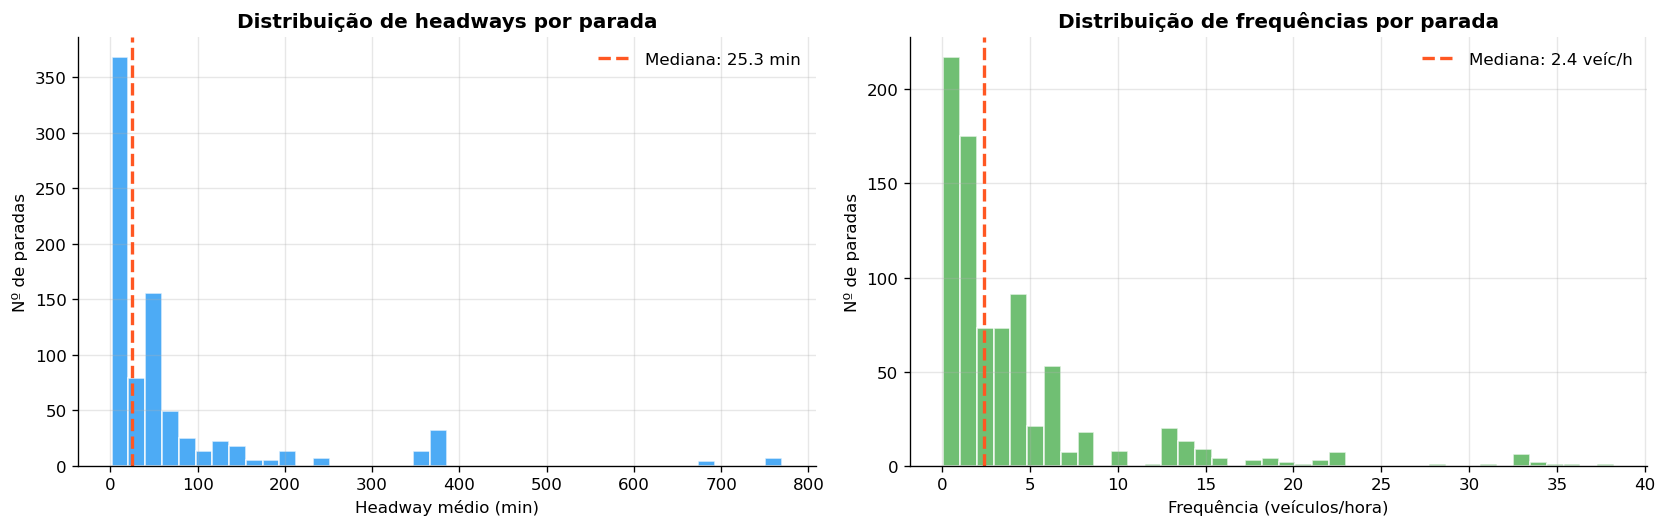

In [10]:
# ── Headway distribution histogram ──────────────────────────────────
hw = stops_gdf["mean_headway"].dropna()
hw = hw[hw > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.hist(hw, bins=40, color=PAL["primary"], edgecolor="white", alpha=0.8)
ax1.axvline(hw.median(), color=PAL["secondary"], linewidth=2, linestyle="--",
            label=f"Mediana: {hw.median():.1f} min")
ax1.set_xlabel("Headway médio (min)")
ax1.set_ylabel("Nº de paradas")
ax1.set_title("Distribuição de headways por parada", fontweight="bold")
ax1.legend(frameon=False)

freq = stops_gdf["frequency_per_hour"].dropna()
freq = freq[freq > 0]
ax2.hist(freq, bins=40, color=PAL["accent"], edgecolor="white", alpha=0.8)
ax2.axvline(freq.median(), color=PAL["secondary"], linewidth=2, linestyle="--",
            label=f"Mediana: {freq.median():.1f} veíc/h")
ax2.set_xlabel("Frequência (veículos/hora)")
ax2.set_ylabel("Nº de paradas")
ax2.set_title("Distribuição de frequências por parada", fontweight="bold")
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

### 3.2 Frequency map

In [11]:
# ── Interactive map: frequency per hour at each stop ─────────────────
gdf = stops_gdf.loc[stops_gdf["frequency_per_hour"] > 0].copy()

fig = px.scatter_mapbox(
    gdf,
    lat="stop_lat", lon="stop_lon",
    size="frequency_per_hour",
    color="frequency_per_hour",
    color_continuous_scale="Plasma_r",
    size_max=14,
    hover_name="stop_name",
    hover_data={
        "num_trips": True,
        "mean_headway": ":.1f",
        "frequency_per_hour": ":.1f",
        "stop_lat": False, "stop_lon": False,
    },
    mapbox_style="carto-positron",
    zoom=11,
    title=f"Frequência por parada ({HEADWAY_START}–{HEADWAY_END})",
)
fig.update_layout(height=600, margin=dict(l=0, r=0, t=40, b=0))
fig.show()

C:\Users\brand\AppData\Local\Temp\ipykernel_6748\629672563.py:4: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


### 3.3 Headway map

In [12]:
# ── Headway map (lower = better service) ─────────────────────────────
gdf_hw = stops_gdf.loc[stops_gdf["mean_headway"] > 0].copy()

fig = px.scatter_mapbox(
    gdf_hw,
    lat="stop_lat", lon="stop_lon",
    size="num_trips",
    color="mean_headway",
    color_continuous_scale="RdYlGn_r",
    size_max=12,
    hover_name="stop_name",
    hover_data={
        "num_trips": True,
        "mean_headway": ":.1f",
        "stop_lat": False, "stop_lon": False,
    },
    mapbox_style="carto-positron",
    zoom=11,
    title=f"Headway médio por parada ({HEADWAY_START}–{HEADWAY_END})",
)
fig.update_layout(height=600, margin=dict(l=0, r=0, t=40, b=0))
fig.show()

C:\Users\brand\AppData\Local\Temp\ipykernel_6748\1031365359.py:4: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



---
## 4 — Route Corridors

Segments with the greatest concentration of overlapping routes.
Built by snapping routes to a common network of inter-stop edges and
counting how many route-directions traverse each segment.

In [13]:
# ── Build route corridor concentration ───────────────────────────────
# Strategy: for each consecutive stop pair in stop_times, count
# how many distinct routes use that segment.

st = feed.stop_times.copy()
trips = feed.trips[["trip_id", "route_id", "direction_id"]]

# Active trips on analysis date
activity = feed.compute_trip_activity([ANALYSIS_DATE])
active_ids = set(activity.loc[activity[ANALYSIS_DATE] > 0, "trip_id"])
st = st.loc[st["trip_id"].isin(active_ids)]

# Merge route info
st = st.merge(trips, on="trip_id")

# Create stop-pair segments
st = st.sort_values(["trip_id", "stop_sequence"])
st["next_stop_id"] = st.groupby("trip_id")["stop_id"].shift(-1)
segments = st.dropna(subset=["next_stop_id"]).copy()

# Unique segment key (sorted pair for bidirectional counting)
segments["seg_key"] = segments.apply(
    lambda r: tuple(sorted([r["stop_id"], r["next_stop_id"]])),
    axis=1,
)

# Count distinct routes per segment
seg_routes = (
    segments
    .groupby("seg_key")
    .agg(
        n_routes=("route_id", "nunique"),
        n_trips=("trip_id", "nunique"),
        stop_a=("stop_id", "first"),
        stop_b=("next_stop_id", "first"),
    )
    .reset_index()
)

print(f"Segments: {len(seg_routes)}")
print(f"Max routes on a segment: {seg_routes['n_routes'].max()}")
print(f"Max trips on a segment: {seg_routes['n_trips'].max()}")

Segments: 1004
Max routes on a segment: 21
Max trips on a segment: 624


In [14]:
# ── Build segment geometries ─────────────────────────────────────────
stop_pts = dict(zip(
    feed.stops["stop_id"],
    gpd.points_from_xy(feed.stops.stop_lon, feed.stops.stop_lat),
))

seg_routes["geometry"] = seg_routes.apply(
    lambda r: sg.LineString([
        stop_pts.get(r["stop_a"], sg.Point(0,0)),
        stop_pts.get(r["stop_b"], sg.Point(0,0)),
    ]),
    axis=1,
)
seg_gdf = gpd.GeoDataFrame(seg_routes, crs=4326)
seg_gdf = seg_gdf.loc[~seg_gdf.geometry.is_empty & seg_gdf.geometry.is_valid]

In [15]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import plotly.graph_objects as go

# ── Corridor concentration map ───────────────────────────────────────
top_segs = seg_gdf.nlargest(500, "n_routes").copy()

# Plotly maps expect lon/lat
if top_segs.crs is not None and top_segs.crs.to_epsg() != 4326:
    top_segs = top_segs.to_crs(4326)

norm = mcolors.Normalize(
    vmin=top_segs["n_routes"].min(),
    vmax=top_segs["n_routes"].max()
)
cmap = cm.get_cmap("YlOrRd")

fig = go.Figure()

for _, row in top_segs.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty:
        continue

    color = mcolors.to_hex(cmap(norm(row["n_routes"])))

    if geom.geom_type == "LineString":
        parts = [geom]
    elif geom.geom_type == "MultiLineString":
        parts = list(geom.geoms)
    else:
        continue

    for part in parts:
        x, y = part.xy
        fig.add_trace(
            go.Scattermapbox(
                lon=list(x),
                lat=list(y),
                mode="lines",
                line=dict(width=3, color=color),
                hovertemplate=(
                    f"Rotas: {row['n_routes']}<extra></extra>"
                ),
                showlegend=False,
            )
        )

fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_zoom=11,
    mapbox_center={
        "lat": feed.stops.stop_lat.mean(),
        "lon": feed.stops.stop_lon.mean(),
    },
    title="Concentração de rotas por segmento",
    height=600,
    margin=dict(l=0, r=0, t=40, b=0),
)

fig.show()

C:\Users\brand\AppData\Local\Temp\ipykernel_6748\2291655478.py:16: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

C:\Users\brand\AppData\Local\Temp\ipykernel_6748\2291655478.py:37: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [16]:
# ── Alternative: line-width map with geopandas explore ───────────────
# (uncomment if plotly map above doesn't render well)

# top_segs.explore(
#     column="n_routes",
#     cmap="YlOrRd",
#     style_kwds={"weight": top_segs["n_routes"] / top_segs["n_routes"].max() * 8 + 1},
#     tooltip=["stop_a", "stop_b", "n_routes", "n_trips"],
# )

---
## 5 — Service Kilometres (VKT)

Daily vehicle-kilometres traveled for all active routes.

In [17]:
# ── Compute trip stats ───────────────────────────────────────────────
trip_stats = feed.compute_trip_stats()

# Filter to active trips
trip_stats = trip_stats.loc[trip_stats["trip_id"].isin(active_ids)]

total_km = trip_stats["distance"].sum()
total_duration = trip_stats["duration"].sum()
total_trips = len(trip_stats)

print(f"Active trips: {total_trips}")
print(f"Total VKT:    {total_km:,.0f} km")
print(f"Total hours:  {total_duration:,.0f} h")
print(f"Avg speed:    {total_km / max(1, total_duration):.1f} km/h")

Active trips: 781
Total VKT:    11,788,239 km
Total hours:  607 h
Avg speed:    19427.3 km/h


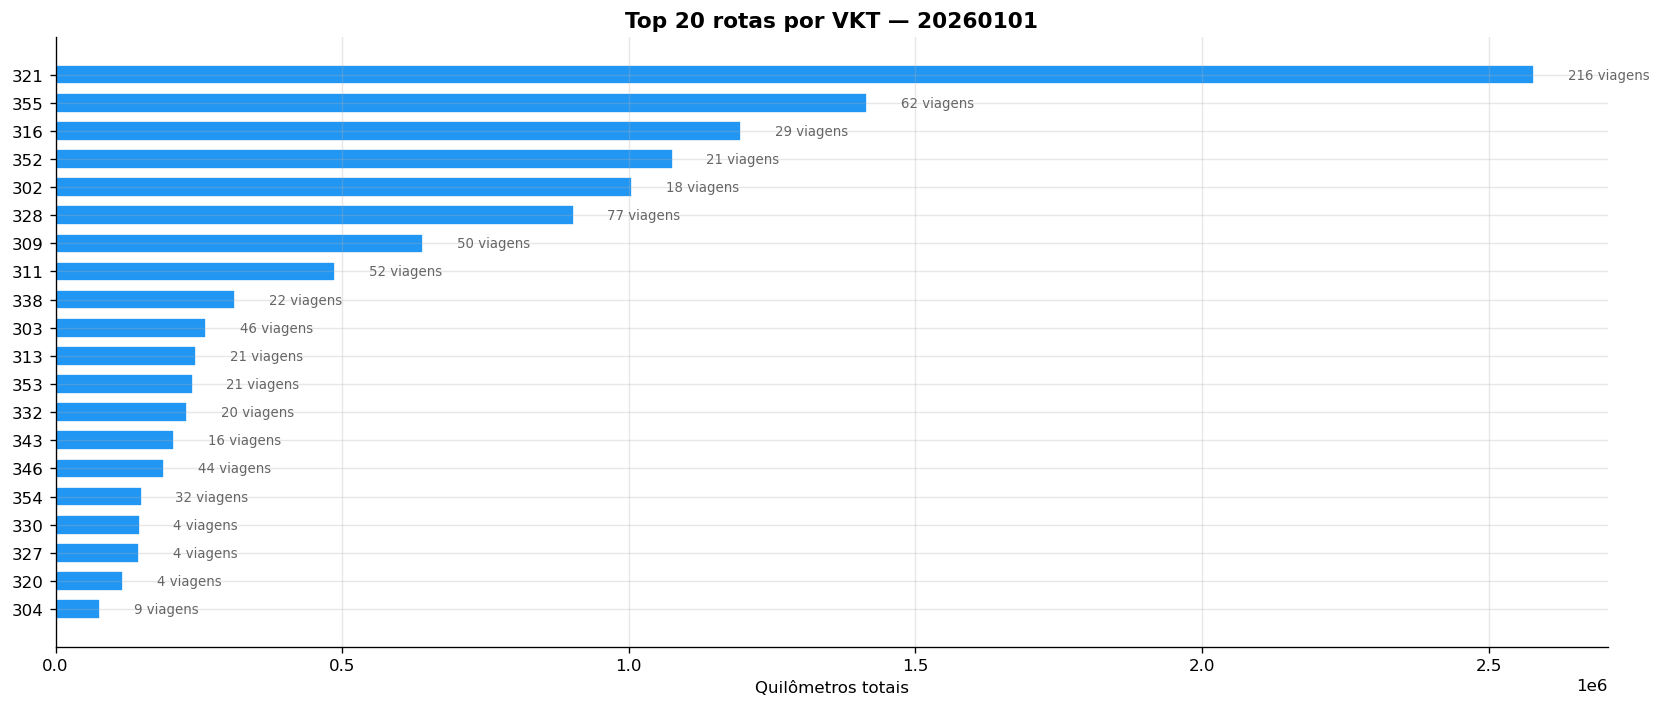

In [18]:
# ── VKT by route (top 20) ───────────────────────────────────────────
route_km = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id"]])
    .merge(feed.routes[["route_id", "route_short_name"]])
    .groupby("route_short_name")
    .agg(
        vkt=("distance", "sum"),
        trips=("trip_id", "count"),
        avg_dist=("distance", "mean"),
        avg_speed=("speed", "mean"),
    )
    .sort_values("vkt", ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 6))
top20 = route_km.head(20)
bars = ax.barh(
    range(len(top20)), top20["vkt"],
    color=PAL["primary"], edgecolor="white", height=0.7,
)

# Add trip count annotations
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row["vkt"] + total_km * 0.005, i,
            f'{row["trips"]:.0f} viagens', va="center", fontsize=8, color="#666")

ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index)
ax.invert_yaxis()
ax.set_xlabel("Quilômetros totais")
ax.set_title(f"Top 20 rotas por VKT — {ANALYSIS_DATE}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

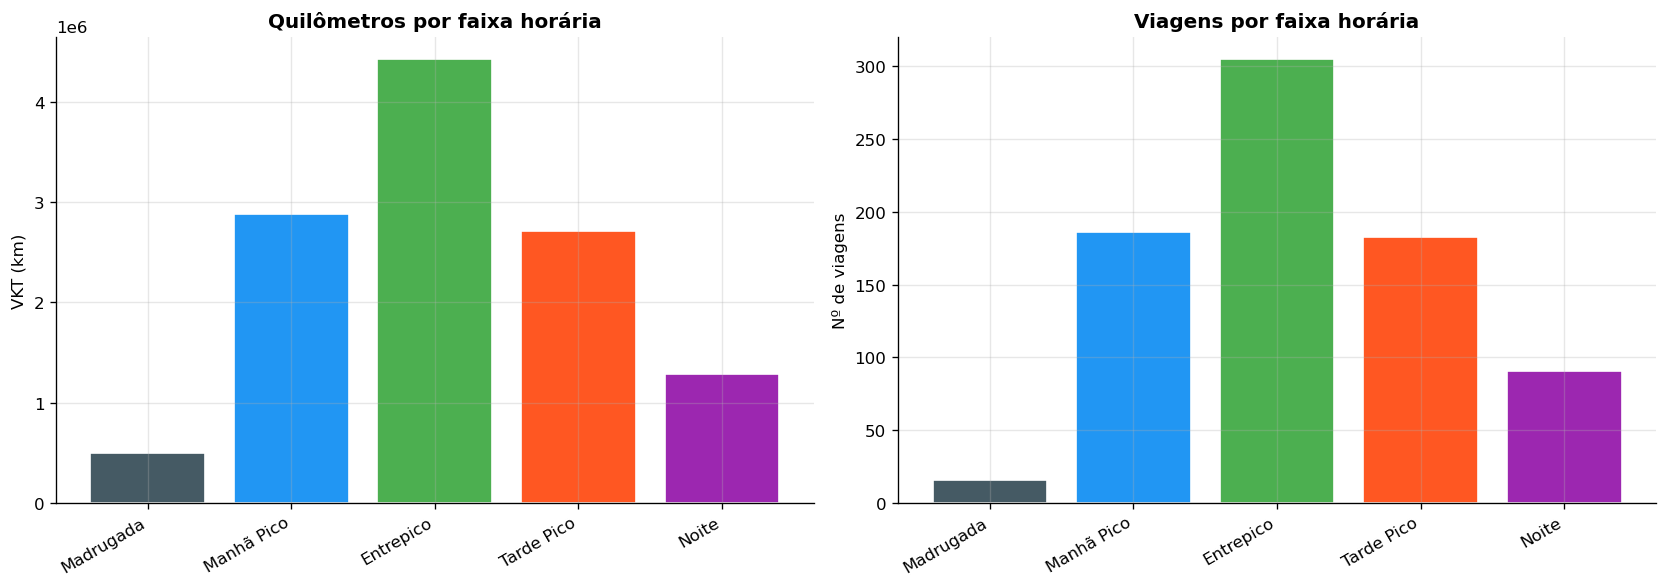

In [19]:
# ── VKT by time window ──────────────────────────────────────────────
def hhmmss_to_hours(s):
    parts = s.split(":")
    return int(parts[0]) + int(parts[1]) / 60

trip_stats["start_hour"] = trip_stats["start_time"].apply(hhmmss_to_hours)

def assign_window(hour):
    for name, t0, t1 in TIME_WINDOWS:
        h0, h1 = hhmmss_to_hours(t0), hhmmss_to_hours(t1)
        if h0 <= hour < h1:
            return name
    return "Outro"

trip_stats["window"] = trip_stats["start_hour"].apply(assign_window)

vkt_by_window = (
    trip_stats
    .groupby("window")
    .agg(trips=("trip_id", "count"), vkt=("distance", "sum"))
)
# Reindex to match TIME_WINDOWS order
vkt_by_window = vkt_by_window.reindex([w[0] for w in TIME_WINDOWS])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(len(vkt_by_window)), vkt_by_window["vkt"],
        color=WINDOW_COLORS, edgecolor="white")
ax1.set_xticks(range(len(vkt_by_window)))
ax1.set_xticklabels(vkt_by_window.index, rotation=30, ha="right")
ax1.set_ylabel("VKT (km)")
ax1.set_title("Quilômetros por faixa horária", fontweight="bold")

ax2.bar(range(len(vkt_by_window)), vkt_by_window["trips"],
        color=WINDOW_COLORS, edgecolor="white")
ax2.set_xticks(range(len(vkt_by_window)))
ax2.set_xticklabels(vkt_by_window.index, rotation=30, ha="right")
ax2.set_ylabel("Nº de viagens")
ax2.set_title("Viagens por faixa horária", fontweight="bold")

plt.tight_layout()
plt.show()

---
## 6 — Trip Summary Table

Comprehensive overview: trips, distances, and durations broken down by
route, time window, and direction.

In [20]:
# ── Route-level summary ──────────────────────────────────────────────
route_summary = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id", "direction_id"]])
    .merge(feed.routes[["route_id", "route_short_name", "route_long_name"]])
    .groupby(["route_short_name", "route_long_name"])
    .agg(
        viagens=("trip_id", "count"),
        km_total=("distance", "sum"),
        km_medio=("distance", "mean"),
        duracao_media_min=("duration", lambda x: x.mean() * 60),
        vel_media_kmh=("speed", "mean"),
    )
    .sort_values("km_total", ascending=False)
    .reset_index()
)

display(
    route_summary
    .head(25)
    .style
    .format({
        "km_total": "{:,.0f}",
        "km_medio": "{:.1f}",
        "duracao_media_min": "{:.0f}",
        "vel_media_kmh": "{:.1f}",
    })
    .background_gradient(subset=["km_total"], cmap="Blues")
    .set_caption(f"Resumo por rota — {ANALYSIS_DATE}")
    .hide(axis="index")
)

route_short_name,route_long_name,viagens,km_total,km_medio,duracao_media_min,vel_media_kmh
321,São Cristóvão / Tangará,216,"2,579,245",11940.9,47,15801.5
355,Botafogo / Chavão,62,"1,415,604",22832.3,60,22892.9
316,São Cristóvão / Santo Antônio,29,"1,196,192",41248.0,92,27878.5
352,São Cristóvão / Santo Antônio,21,"1,076,598",51266.6,106,29350.6
302,São Cristóvão / Agrisa,18,"1,005,488",55860.4,113,30692.7
328,São Cristóvão / Peró,77,"903,565",11734.6,41,17537.5
309,São Cristóvão / Parque Eldorado,50,"640,745",12814.9,43,18321.5
311,Contorno / Vila do Sol,52,"487,094",9367.2,32,18678.4
338,São Cristóvão / Guriri,22,"313,060",14230.0,46,19333.4
303,Contorno / Jardim Caiçara,46,"262,004",5695.7,27,13080.5


In [21]:
# ── Cross-tabulation: trips by route × time window ──────────────────
ts_enriched = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id"]])
    .merge(feed.routes[["route_id", "route_short_name"]])
)

cross = (
    ts_enriched
    .groupby(["route_short_name", "window"])["trip_id"]
    .count()
    .unstack(fill_value=0)
)
# Reorder columns
cross = cross.reindex(columns=[w[0] for w in TIME_WINDOWS], fill_value=0)
cross["TOTAL"] = cross.sum(axis=1)
cross = cross.sort_values("TOTAL", ascending=False)

display(
    cross
    .head(20)
    .style
    .background_gradient(cmap="YlOrRd", axis=None,
                          subset=[w[0] for w in TIME_WINDOWS])
    .set_caption("Viagens por rota × faixa horária")
)

window,Madrugada,Manhã Pico,Entrepico,Tarde Pico,Noite,TOTAL
route_short_name,,,,,,
321,6,54,85,47,24,216
328,0,17,34,17,9,77
355,1,13,24,13,11,62
311,0,13,20,13,6,52
309,1,14,18,12,5,50
303,0,10,19,14,3,46
346,0,10,17,9,8,44
354,0,0,15,10,7,32
316,3,8,11,5,2,29


In [22]:
# ── Grand totals ─────────────────────────────────────────────────────
grand = pd.DataFrame({
    "Indicador": [
        "Rotas ativas",
        "Viagens totais",
        "VKT total (km)",
        "Km médio por viagem",
        "Duração média (min)",
        "Velocidade média (km/h)",
        "Horas-veículo totais",
    ],
    "Valor": [
        f"{route_summary['route_short_name'].nunique()}",
        f"{total_trips:,}",
        f"{total_km:,.0f}",
        f"{total_km / max(1, total_trips):.1f}",
        f"{total_duration / max(1, total_trips) * 60:.0f}",
        f"{total_km / max(1, total_duration):.1f}",
        f"{total_duration:,.0f}",
    ],
})

display(
    grand.style
    .set_properties(**{"font-weight": "bold"}, subset=["Indicador"])
    .hide(axis="index")
    .set_caption(f"Totais do dia — {ANALYSIS_DATE}")
)

Indicador,Valor
Rotas ativas,23
Viagens totais,781
VKT total (km),"11,788,239"
Km médio por viagem,15093.8
Duração média (min),47
Velocidade média (km/h),19427.3
Horas-veículo totais,607


---
## 7 — Diagnostics

Anomaly detection and quality indicators derived from the GTFS data.

### 7.1 Speed anomalies

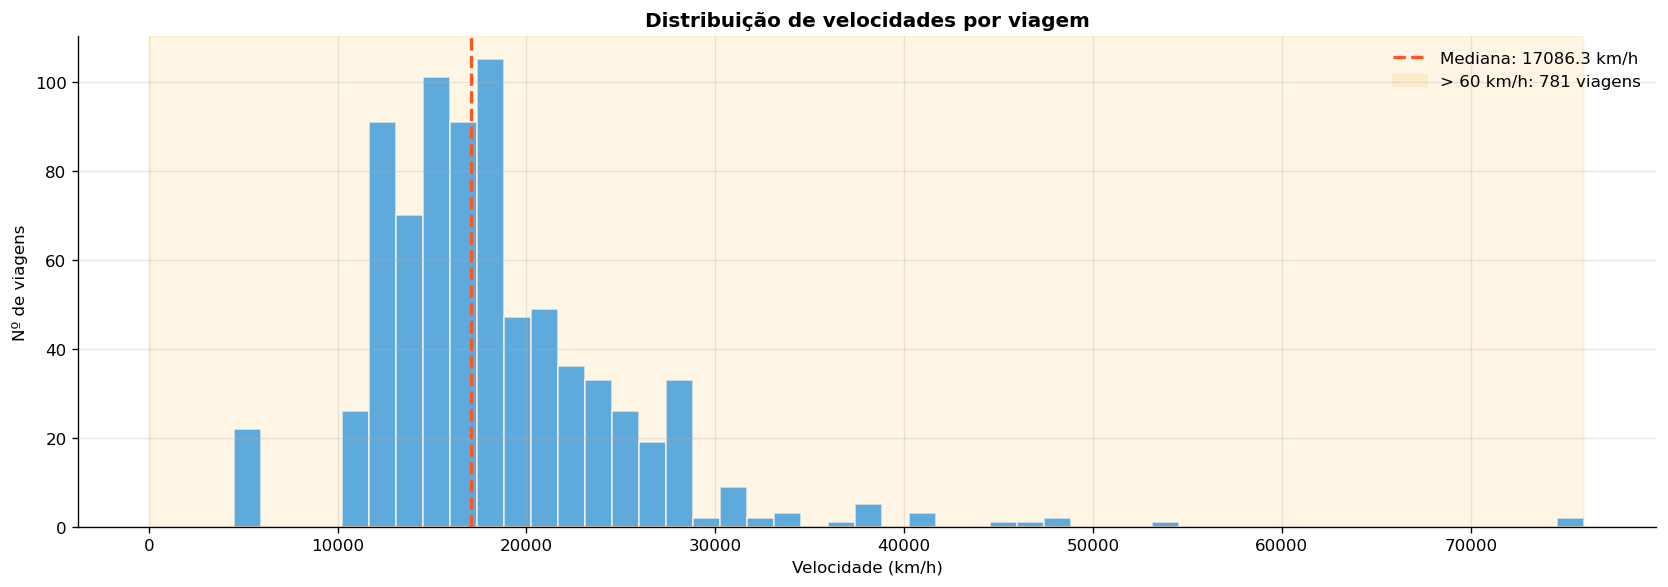

In [23]:
# ── Speed distribution per route ─────────────────────────────────────
ts_spd = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id"]])
    .merge(feed.routes[["route_id", "route_short_name"]])
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(ts_spd["speed"].dropna(), bins=50, color=PAL["primary"],
        edgecolor="white", alpha=0.8)
ax.axvline(ts_spd["speed"].median(), color=PAL["secondary"], linestyle="--",
           linewidth=2, label=f"Mediana: {ts_spd['speed'].median():.1f} km/h")

# Flag extremes
slow = ts_spd.loc[ts_spd["speed"] < 5]
fast = ts_spd.loc[ts_spd["speed"] > 60]
if not slow.empty:
    ax.axvspan(0, 5, alpha=0.1, color="red", label=f"< 5 km/h: {len(slow)} viagens")
if not fast.empty:
    ax.axvspan(60, ts_spd["speed"].max(), alpha=0.1, color="orange",
               label=f"> 60 km/h: {len(fast)} viagens")

ax.set_xlabel("Velocidade (km/h)")
ax.set_ylabel("Nº de viagens")
ax.set_title("Distribuição de velocidades por viagem", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

if not slow.empty:
    print(f"\n⚠ {len(slow)} viagens com velocidade < 5 km/h (possível erro de dados):")
    display(
        slow.nsmallest(5, "speed")
        [["route_short_name", "trip_id", "distance", "duration", "speed"]]
    )

### 7.2 Stop spacing

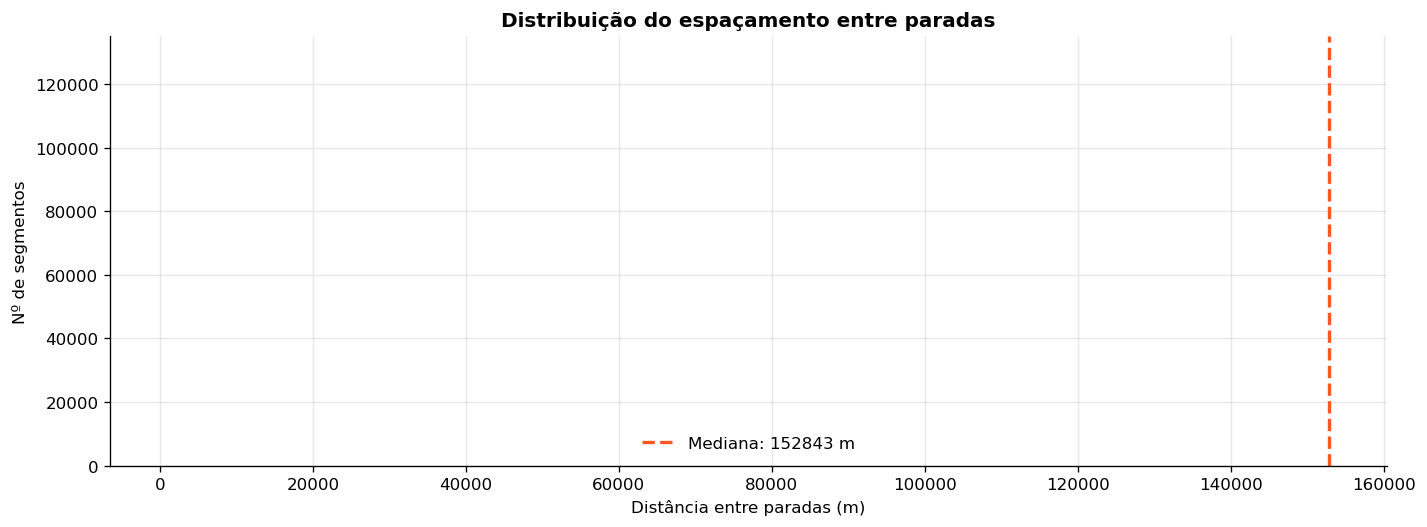

Espaçamento mediano: 152843 m
Segmentos > 2 km: 128660 (99.9%)
Segmentos < 100 m: 0 (0.0%)


In [24]:
# ── Inter-stop distance distribution ─────────────────────────────────
st_dist = feed.stop_times.copy()
st_dist = st_dist.sort_values(["trip_id", "stop_sequence"])
st_dist["next_dist"] = st_dist.groupby("trip_id")["shape_dist_traveled"].shift(-1)
st_dist["segment_km"] = st_dist["next_dist"] - st_dist["shape_dist_traveled"]
st_dist = st_dist.dropna(subset=["segment_km"])
st_dist = st_dist.loc[st_dist["segment_km"] > 0]

fig, ax = plt.subplots(figsize=(12, 4.5))
seg_m = st_dist["segment_km"] * 1000  # to metres
ax.hist(seg_m.clip(upper=2000), bins=80, color=PAL["accent"], edgecolor="white", alpha=0.8)
ax.axvline(seg_m.median(), color=PAL["secondary"], linestyle="--", linewidth=2,
           label=f"Mediana: {seg_m.median():.0f} m")
ax.set_xlabel("Distância entre paradas (m)")
ax.set_ylabel("Nº de segmentos")
ax.set_title("Distribuição do espaçamento entre paradas", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Espaçamento mediano: {seg_m.median():.0f} m")
print(f"Segmentos > 2 km: {(seg_m > 2000).sum()} ({(seg_m > 2000).mean()*100:.1f}%)")
print(f"Segmentos < 100 m: {(seg_m < 100).sum()} ({(seg_m < 100).mean()*100:.1f}%)")

### 7.3 Trip duration outliers

In [25]:
# ── Box plot of trip duration by route (top 15 by trip count) ────────
ts_dur = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id"]])
    .merge(feed.routes[["route_id", "route_short_name"]])
)
ts_dur["duration_min"] = ts_dur["duration"] * 60

top_routes = ts_dur["route_short_name"].value_counts().head(15).index
ts_dur_top = ts_dur.loc[ts_dur["route_short_name"].isin(top_routes)]

fig = px.box(
    ts_dur_top,
    x="route_short_name", y="duration_min",
    color="route_short_name",
    title="Duração das viagens por rota (top 15)",
    labels={"route_short_name": "Rota", "duration_min": "Duração (min)"},
)
fig.update_layout(showlegend=False, height=500)
fig.show()

### 7.4 Feed completeness

In [26]:
# ── Check for common GTFS issues ────────────────────────────────────
checks = []

# Trips without stop_times
orphan_trips = set(feed.trips["trip_id"]) - set(feed.stop_times["trip_id"])
checks.append(("Viagens sem stop_times", len(orphan_trips),
               "✓" if not orphan_trips else f"⚠ {len(orphan_trips)}"))

# Stops without any visits
visited = set(feed.stop_times["stop_id"])
all_stops = set(feed.stops["stop_id"])
unused = all_stops - visited
checks.append(("Paradas sem visitas", len(unused),
               "✓" if not unused else f"⚠ {len(unused)}"))

# Routes without trips
routes_with_trips = set(feed.trips["route_id"])
all_routes = set(feed.routes["route_id"])
unused_routes = all_routes - routes_with_trips
checks.append(("Rotas sem viagens", len(unused_routes),
               "✓" if not unused_routes else f"⚠ {len(unused_routes)}"))

# Shapes coverage
if feed.shapes is not None:
    shapes_used = set(feed.trips["shape_id"].dropna())
    shapes_defined = set(feed.shapes["shape_id"])
    missing_shapes = shapes_used - shapes_defined
    checks.append(("Shapes faltando", len(missing_shapes),
                   "✓" if not missing_shapes else f"⚠ {len(missing_shapes)}"))

# Null arrival times
null_arr = feed.stop_times["arrival_time"].isna().sum()
checks.append(("stop_times sem arrival_time", null_arr,
               "✓" if null_arr == 0 else f"⚠ {null_arr}"))

# shape_dist_traveled coverage
null_dist = feed.stop_times["shape_dist_traveled"].isna().sum()
pct_null = null_dist / len(feed.stop_times) * 100
checks.append(("shape_dist_traveled nulo", null_dist,
               "✓" if pct_null < 1 else f"⚠ {null_dist} ({pct_null:.1f}%)"))

display(
    pd.DataFrame(checks, columns=["Verificação", "Contagem", "Status"])
    .style
    .applymap(lambda v: "color: green" if v == "✓" else "color: #D32F2F",
              subset=["Status"])
    .hide(axis="index")
    .set_caption("Diagnóstico de completude do feed")
)

Verificação,Contagem,Status
Viagens sem stop_times,0,✓
Paradas sem visitas,0,✓
Rotas sem viagens,0,✓
Shapes faltando,0,✓
stop_times sem arrival_time,0,✓
shape_dist_traveled nulo,0,✓


### 7.5 Route stats table (full)

In [27]:
# ── Full route stats via gtfs_kit ────────────────────────────────────
route_stats = feed.compute_route_stats(
    [ANALYSIS_DATE],
    headway_start_time=HEADWAY_START,
    headway_end_time=HEADWAY_END,
    split_directions=False,
)

display(
    route_stats
    .sort_values("service_distance", ascending=False)
    .head(20)
    .style
    .format({
        "max_headway": "{:.0f}",
        "mean_headway": "{:.0f}",
        "service_distance": "{:,.1f}",
        "service_duration": "{:.1f}",
        "service_speed": "{:.1f}",
    })
    .background_gradient(subset=["service_distance"], cmap="Blues")
    .set_caption("Estatísticas de rotas (gtfs_kit)")
    .hide(axis="index")
)

date,route_id,route_short_name,route_type,num_trips,num_trip_starts,num_trip_ends,num_stop_patterns,is_loop,start_time,end_time,max_headway,min_headway,mean_headway,peak_num_trips,peak_start_time,peak_end_time,service_distance,service_duration,service_speed,mean_trip_distance,mean_trip_duration,is_bidirectional
20260101,r321,321,3,216,216,214,2,0,00:05:00,24:10:00,20,2.000000,10,13,18:30:00,18:35:00,"2,579,244.7",169.2,15240.8,11940.947500,0.783488,1
20260101,r355,355,3,62,62,61,2,0,00:00:00,24:00:00,45,25.000000,35,4,06:45:00,07:10:00,"1,415,604.3",62.0,22832.3,22832.327000,1.000000,1
20260101,r316,316,3,29,29,28,2,0,01:20:00,24:30:00,120,30.000000,74,4,05:50:00,06:30:00,"1,196,192.1",44.6,26830.5,41248.004069,1.537356,1
20260101,r352,352,3,21,21,21,2,0,00:00:00,23:20:00,150,60.000000,104,4,18:15:00,18:50:00,"1,076,598.0",37.0,29097.2,51266.569857,1.761905,1
20260101,r302,302,3,18,18,18,2,0,03:32:00,23:00:00,150,110.000000,134,3,06:30:00,06:50:00,"1,005,487.6",33.9,29675.0,55860.423500,1.882407,1
20260101,r328,328,3,77,77,77,2,0,05:40:00,23:35:00,50,15.000000,27,4,08:00:00,08:20:00,"903,564.6",52.5,17205.3,11734.605156,0.682035,1
20260101,r309,309,3,50,50,50,2,0,04:50:00,22:35:00,75,20.000000,42,3,08:00:00,08:25:00,"640,745.2",35.9,17839.8,12814.903500,0.718333,1
20260101,r311,311,3,52,52,52,2,0,05:30:00,23:20:00,75,8.000000,39,2,07:00:00,07:55:00,"487,094.5",27.8,17521.4,9367.201500,0.534615,1
20260101,r338,338,3,22,22,22,2,0,05:00:00,23:10:00,125,90.000000,110,2,05:50:00,06:20:00,"313,059.7",16.8,18690.1,14229.987500,0.761364,1
20260101,r303,303,3,46,46,46,2,0,05:55:00,21:35:00,65,20.000000,41,2,07:00:00,07:30:00,"262,004.2",20.5,12780.7,5695.742500,0.445652,1


---

### Notas metodológicas

- **Data de análise**: dia mais movimentado do feed (auto-detectado).
- **Headways**: calculados entre 06:00–22:00 (configurável).
- **VKT**: quilômetros-veículo percorridos; derivado de `shape_dist_traveled`.
- **Velocidade**: distância total / duração total por viagem.
- **Corredores**: segmentos entre paradas consecutivas, contando rotas distintas.
- **Ferramentas**: `gtfs_kit` (análise), `plotly` (mapas), `matplotlib` (gráficos).